## EEG During mental arithmetic

This data has been extracted from https://physionet.org/content/eegmat/1.0.0/
Original publication: https://physionet.org/content/eegmat/1.0.0/

Otra fuente posible: https://openneuro.org/

In [21]:
import mne
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Initial raw data exploration

In [22]:
subject_info = pd.read_csv("../../data/EEG/subject-info.csv")
subject_info.head() # ---> Get classes for MEDA visualization from here.

,Subject,Age,Gender,Recording year,Number of subtractions,Count quality
0,Subject00,21,F,2011,9.70,0
1,Subject01,18,F,2011,29.35,1
2,Subject02,19,F,2012,12.88,1
3,Subject03,17,F,2010,31.00,1
4,Subject04,17,F,2010,8.60,0


In [23]:
subject_ids             = subject_info["Subject"].to_numpy()
subject_ages            = subject_info["Age"].to_numpy()
subject_genders         = subject_info["Gender"].to_numpy()
subject_rec_years       = subject_info["Recording year"].to_numpy()
subject_n_subtractions  = subject_info["Number of subtractions"].to_numpy()
subject_quality         = subject_info["Count quality"].to_numpy()
operations = [1, 2]
operation_labels = ["Baseline", "Arithmetic"]

In [24]:
subject_id = subject_ids[0]
operation = operations[1]
file = f"../../data/EEG/{subject_id}_{operation}.edf"
data = mne.io.read_raw_edf(file)
raw_data = data.get_data()[:, :-1000]
info = data.info
channels = data.ch_names

Extracting EDF parameters from ../../data/EEG/Subject00_2.edf...
Setting channel info structure...
Creating raw.info structure...


In [25]:
print(f"There are:\n - {len(subject_ids)} subjects. \n - {len(channels)} channels. \nSampling rate: 500.0Hz")

There are:
 - 36 subjects. 
 - 21 channels. 
Sampling rate: 500.0Hz


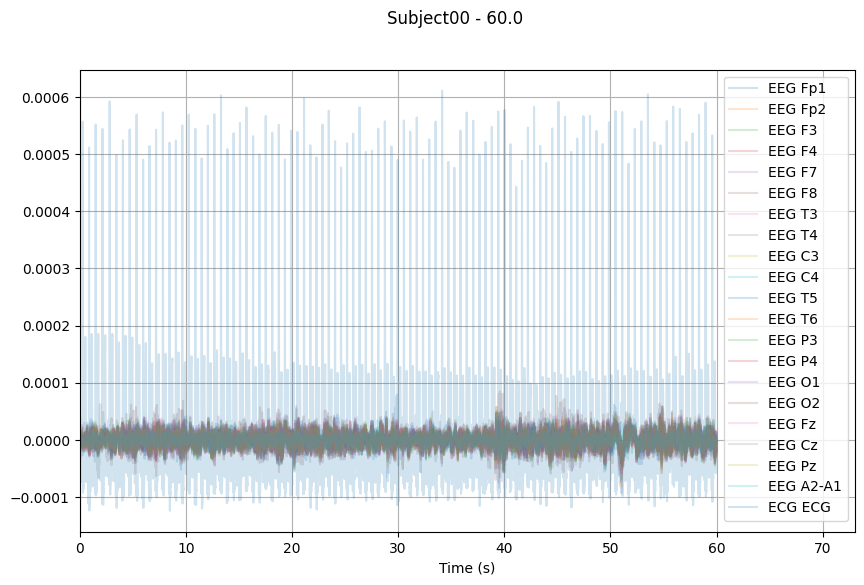

In [26]:

test_signal = raw_data[:, :].T
time = np.linspace(0, 60, test_signal.shape[0])
fig, ax = plt.subplots(1,1, figsize=(10,6))
fig.suptitle(f"{subject_id} - {raw_data.shape[1]/500.0}")
ax.plot(time, test_signal, label=channels, alpha=0.2)
ax.grid(True)
ax.legend()
ax.set_xlabel("Time (s)");
ax.set_xlim(0, 73);


### Build tensor

Tensor: operación $\times$ tiempo $\times$ frecuencias $\times$ channel $\times$ individuo

Dimensiones: 2 $\times$ ?? $\times$  ?? $\times$ 21 $\times$ 36


In [42]:
import mne
import numpy as np
from msa.feature_extraction.features import *

In [ ]:
# STFT parameters
sr = 500.0 # Hz
win_samples = int(0.50*sr) # samples
hop = int(0.25*sr) # samples
window = "blackman"
padding = "zeros"

max_signal_lenght = 180*500
n_windows = get_n_windows(np.zeros(max_signal_lenght), sr, win_samples, hop, window, padding)
n_frequencies = get_n_frequencies(sr, win_samples, hop, window, padding)


In [ ]:
X_tensor = np.empty((len(operations), n_windows, n_frequencies, len(channels), len(subject_ids)))
time = np.empty()
freqs = np.empty()
for i, operation in enumerate(operations[:]):
    for j, subject_id in enumerate(subject_ids[:]):
            file = f"../../data/EEG/{subject_id}_{operation}.edf"
            data = mne.io.read_raw_edf(file)
            raw_data = data.get_data()[:-1000] # Quitamos los últimos 2 segundos, que son artificios.
            channels = data.ch_names

            for k, signal in enumerate(raw_data):
                time, freq, Zxx = stft(signal, sr, win_samples, hop, window, padding)
                X_tensor[i, :, :, k, j] = Zxx

Extracting EDF parameters from ../../data/EEG/Subject00_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subject01_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subject02_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subject03_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subject04_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subject05_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subject06_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subject07_1.edf...
Setting channel info stru

In [ ]:
np.save("../../data/EEG/data.npy", X_tensor)
X_tensor.shape